In [1]:
import numpy as np

import scarf

scarf.configure_output(level='WARNING', progress=True)

counts = scarf.cytebase.connect("scarf_docs").download(
    'tenx_5K_pbmc_rnaseq/data.h5',
    destination='scarf_datasets',
)[0]

store = counts.with_name('data.zarr')
reader = scarf.CrH5Reader(str(counts))
scarf.CrToZarr(
    reader,
    zarr_loc=str(store),
).dump()

ds = scarf.DataStore(
    str(store),
    nthreads=4,
    min_features_per_cell=10,
)

Downloading bucket files: 18098007 / 18098007 complete

Downloading bytes: 18098007 / 18098007 complete

Writing counts: 3 / 3 complete

Computing RNA initialization statistics: 3 / 3 complete

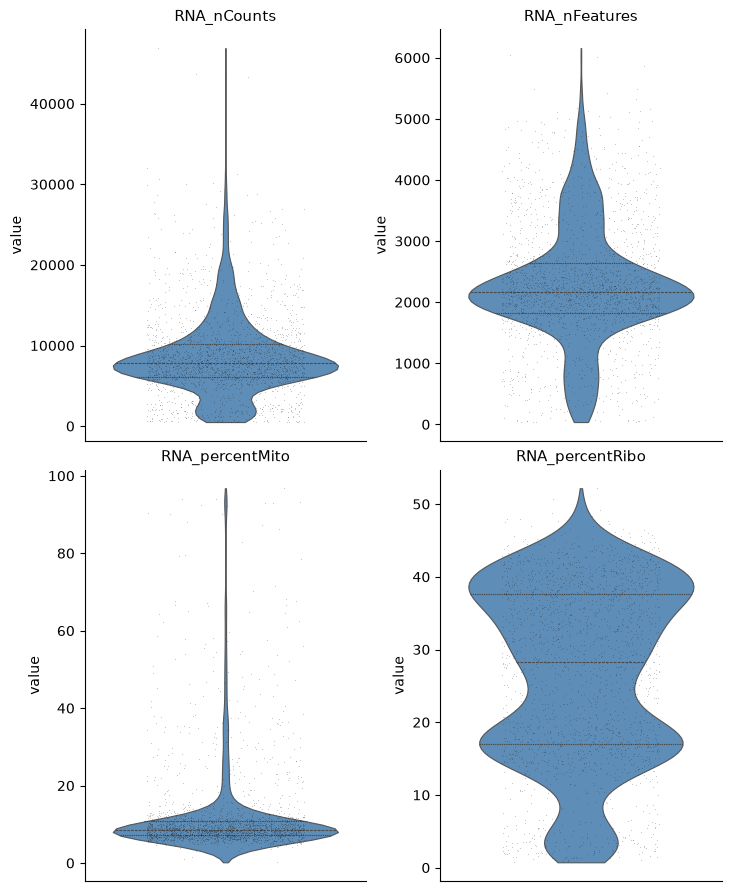

In [2]:
qc_cols = [
    c for c in (
        'RNA_nCounts', 'RNA_nFeatures', 'RNA_percentMito', 'RNA_percentRibo'
    )
    if c in ds.cells.columns
]
ds.plots.distribution(
    keys=qc_cols,
    kind='violin',
    max_points=2000,
)

Active cells before filter: 5025
Active cells after filter: 3940


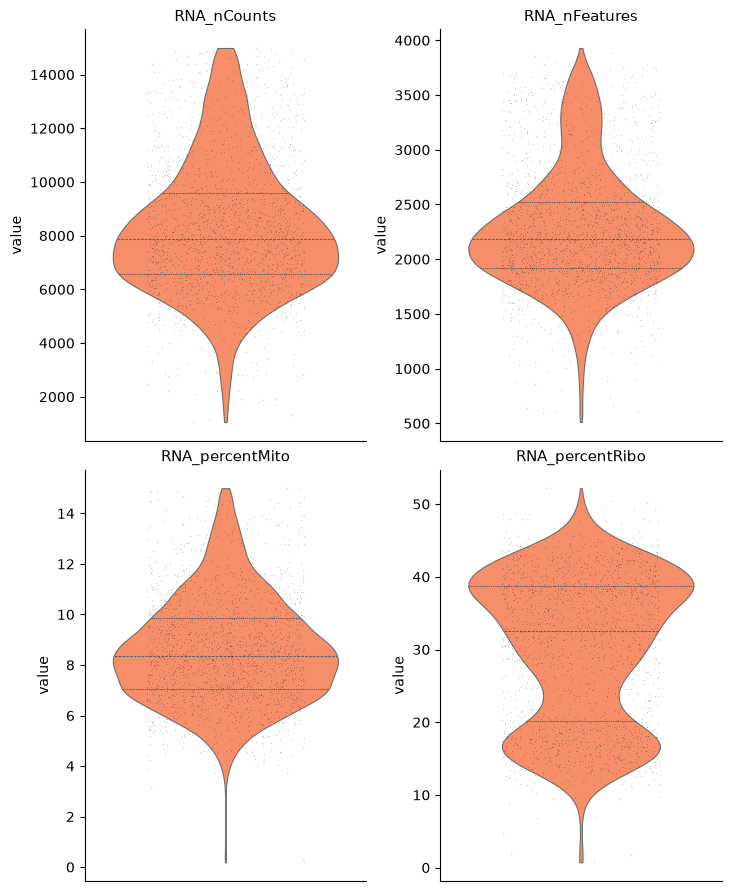

In [3]:
n_before = int(ds.cells.fetch_all('I').sum())
ds.filter_cells(
    attrs=['RNA_nCounts', 'RNA_nFeatures', 'RNA_percentMito'],
    highs=[15000, 4000, 15],
    lows=[1000, 500, 0],
    reset_previous=True,
)
n_after = int(ds.cells.fetch_all('I').sum())
print(f'Active cells before filter: {n_before}')
print(f'Active cells after filter: {n_after}')
ds.plots.distribution(
    keys=qc_cols,
    kind='violin',
    max_points=2000,
    color='coral',
)

In [4]:
ds.RNA.add_percent_feature(feat_pattern='^HB[AB]', name='RNA_percentHB')
if 'RNA_percentHB' in ds.cells.columns:
    print(
        ds.cells.to_pandas_dataframe(['RNA_percentHB'], key='I')['RNA_percentHB']
        .describe()
    )
else:
    print('No features matched ^HB[AB] in this store')

(RNA) Computing RNA_percentHB: 3 / 3 complete

count    3940.000000
mean        0.000758
std         0.015413
min         0.000000
25%         0.000000
50%         0.000000
75%         0.000000
max         0.584795
Name: RNA_percentHB, dtype: float64


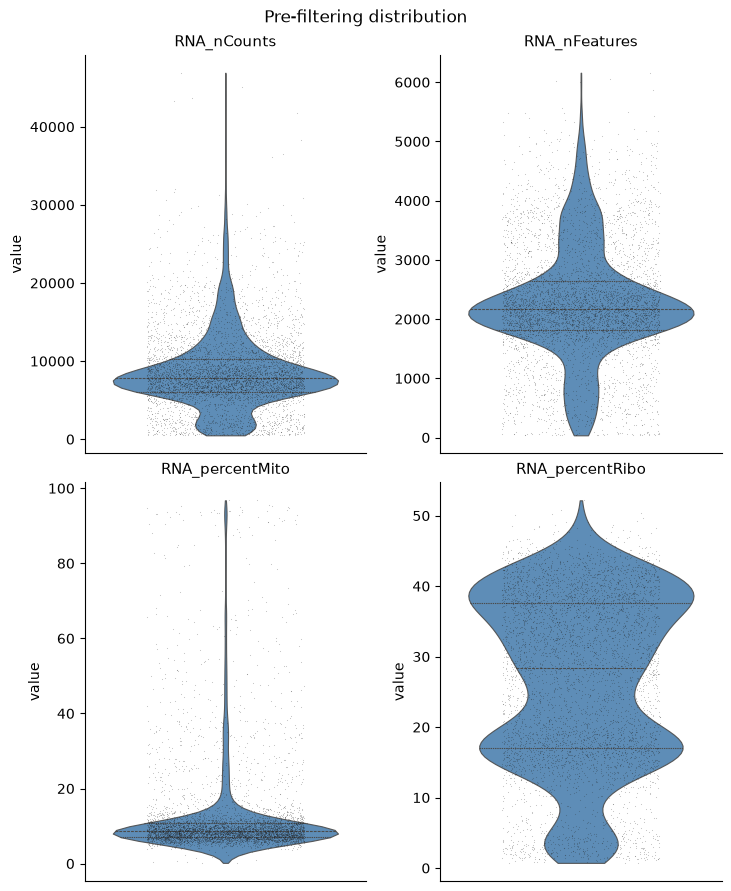

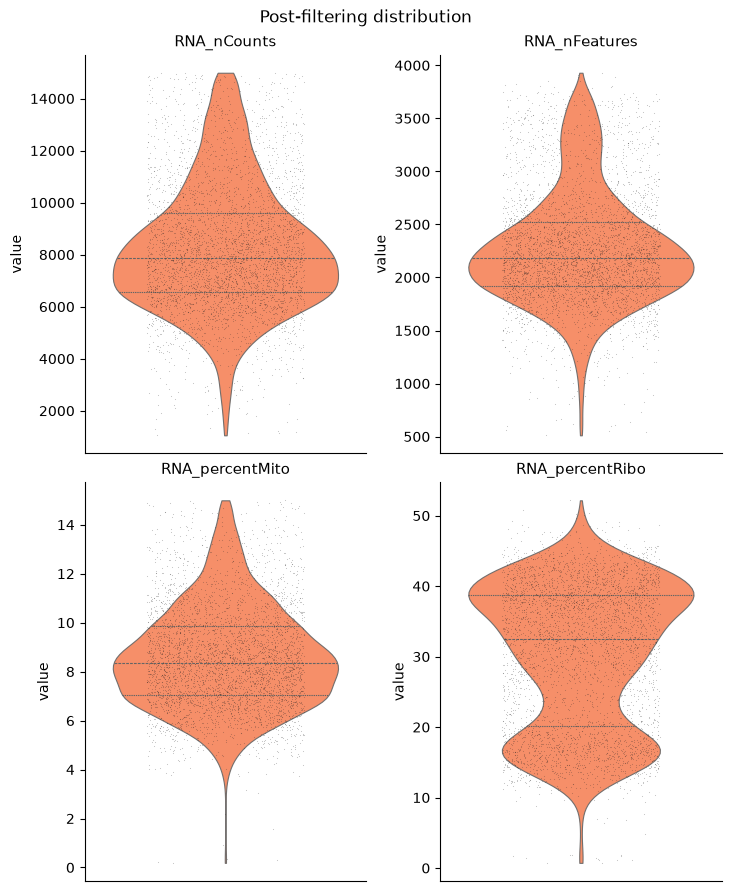

In [5]:
ds.auto_filter_cells(show_qc_plots=True)

In [6]:
ds.cells.insert(
    "qc_sample",
    np.asarray(
        [f"sample_{index % 4}" for index in range(ds.cells.N)]
    ),
    overwrite=True,
)
ds.cells.reset_key(key="I")
ds.auto_filter_cells(
    attrs=qc_cols,
    sample_column="qc_sample",
    n_mads=3.0,
    min_cells_per_sample=20,
    show_qc_plots=False,
)

In [7]:
ds.mark_hvgs(min_cells=20, top_n=500, show_plot=False)
ds.run_normalization(feat_key='hvgs')
ds.run_pca(dims=15)
ds.build_embedding_initialization()
ds.build_ann_index()
ds.query_neighbors(k=11)
ds.build_connectivity_map()
ds.run_leiden_clustering(resolution=0.5)
score_col = ds.run_doublet_detection(cluster_key='RNA_leiden_cluster')
ds.run_umap(n_epochs=100, spread=5, min_dist=1, parallel=True)

Computing RNA feature statistics: 6 / 6 complete

Writing data: 1 / 1 complete

Fitting PCA: 1 / 1 complete

Writing reduced coordinates: 1 / 1 complete

Calculating reduced coordinates: 1 / 1 complete

...

Identifying neighbors: 1 / 1 complete

Writing simulated doublets: 3 / 3 complete

Computing RNA initialization statistics: 3 / 3 complete

Training UMAP: 100 / 100 complete

ArtifactRef(assay='RNA', kind='embedding', artifact_id='add50f9b9a71...')

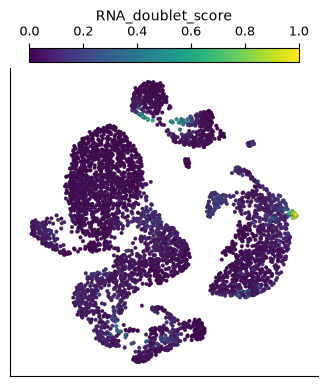

In [8]:
ds.plots.embedding(
    layout_key='RNA_UMAP',
    color_by=score_col,
)

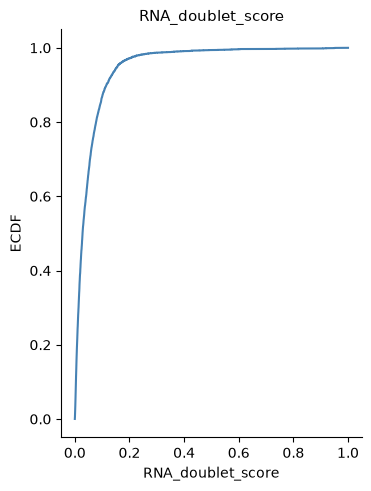

In [9]:
ds.plots.distribution(
    keys=score_col,
    kind="ecdf",
)